In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [13]:
# 1 imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
exp_name = "exp18_swin_384_strong_MSELoss_Eyes_AuxBCEWeightedLoss_StrongHead"

main_folder = "../.."
img_folder  = os.path.join(main_folder, "data", "train")
out_dir     = os.path.join(main_folder, "outputs", "extra","exp18_aux_heads_metadata_weightedBCELoss", exp_name)
out_csv     = os.path.join(main_folder, "data", "train.csv")

os.makedirs(out_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#  generate aux-labels if not already done, load CSV, set cfg
from src.utils import build_binary_aux_cfg
import sys
sys.path.insert(0, os.path.join(main_folder))

TARGET = "Pawpularity"
df = pd.read_csv(os.path.join(main_folder, "data", "train.csv"))

# --- set cfg ---
cfg = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg["img_size"] = 384
cfg["name"]     = exp_name
cfg["loss"]     = "mse"
cfg["head_type"] = "mlp"#strong head , linear or mlp
cfg["aux_tasks"]          = []                    # no regression aux
cfg["binary_aux_tasks"]   = ["Eyes"]
cfg["aux_loss_weights"]   = {
    "Eyes":      0.1,
}

cfg["binary_aux_loss_type"] = "weighted_bce"

# pos_weight  = majority_count / minority_count  -> passed to BCEWithLogitsLoss to
#               up-weight the rare class during training.
# flip_targets = tasks where class 0 is the minority; labels are flipped to 1
#               so BCE always treats the minority as the positive class.because PyTorch's pos_weight only applies
#               to label=1 samples  without flipping it would have no effect on
#               the minority class when it is label 0
pos_weight_dict, flip_targets_list = build_binary_aux_cfg(df, cfg["binary_aux_tasks"])
print("pos_weight_dict:", pos_weight_dict, "flip_targets_list:", flip_targets_list)
cfg["binary_aux_pos_weight"]   = pos_weight_dict
cfg["binary_aux_flip_targets"] = flip_targets_list

cfg["use_saliency"]       = False

save_config(cfg, out_dir)
set_seed(cfg["seed"])



  Eyes: class_0=2254, class_1=7658   minority=class_0, flip target, pos_weight=3.40
pos_weight_dict: {'Eyes': np.float64(3.3975155279503104)} flip_targets_list: ['Eyes']


In [6]:
df.head()

,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,0007de18844b0dbbb5e1f607da0606e0,0,1,1,1,0,0,1,0,0,0,0,0,63
1,0009c66b9439883ba2750fb825e1d7db,0,1,1,0,0,0,0,0,0,0,0,0,42
2,0013fd999caf9a3efe1352ca1b0d937e,0,1,1,1,0,0,0,0,1,1,0,0,28
3,0018df346ac9c1d8413cfcc888ca8246,0,1,1,1,0,0,0,0,0,0,0,0,15
4,001dc955e10590d3ca4673f034feeef2,0,0,0,1,0,0,1,0,0,0,0,0,72


In [7]:

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)
    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp18_swin_384_strong_MSELoss_Eyes_AuxBCEWeightedLoss_StrongHead: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: PawRMSE=23.7580 TotalLoss=564.5527 | ValRMSE: 21.0326 | train_loss_Eyes: 1.0824 | train_train_acc_Eyes: 0.5144 | Eyes_val_bce: 0.6913 | Eyes_val_acc: 0.7211 | Eyes_val_f1: 0.1659 | Eyes_val_prec: 0.2371 | Eyes_val_rec: 0.1276
Epoch 2/10 | Fold 1 | Train[MSE]: PawRMSE=20.5218 TotalLoss=421.2515 | ValRMSE: 21.0588 | train_loss_Eyes: 1.0816 | train_train_acc_Eyes: 0.5165 | Eyes_val_bce: 0.7173 | Eyes_val_acc: 0.2173 | Eyes_val_f1: 0.3571 | Eyes_val_prec: 0.2173 | Eyes_val_rec: 1.0000
Epoch 3/10 | Fold 1 | Train[MSE]: PawRMSE=20.5056 TotalLoss=420.5866 | ValRMSE: 21.0166 | train_loss_Eyes: 1.0782 | train_train_acc_Eyes: 0.5129 | Eyes_val_bce: 0.6495 | Eyes_val_acc: 0.7827 | Eyes_val_f1: 0.0000 | Eyes_val_prec: 0.0000 | Eyes_val_rec: 0.0000
Epoch 4/10 | Fold 1 | Train[MSE]: PawRMSE=20.4978 TotalLoss=420.2688 | ValRMSE: 21.0231 | train_loss_Eyes: 1.0839 | train_train_acc_Eyes: 

In [6]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.8835 (n=1983)
Fold 2 OOF RMSE: 18.2335 (n=1983)
Fold 3 OOF RMSE: 17.2061 (n=1982)
Fold 4 OOF RMSE: 17.7393 (n=1982)
Fold 5 OOF RMSE: 17.9594 (n=1982)


In [8]:
# aux-task validation metrics 



baseline_rmse_path = os.path.join(
    "../..", "outputs", "extra", "exp3_swin_384_strong_MSE_MLPHead", "fold_rmse.npy"
)
aux_rmse_path = os.path.join(out_dir, "fold_rmse.npy")

if os.path.exists(baseline_rmse_path) and os.path.exists(aux_rmse_path):
    fold_rmse_base = np.load(baseline_rmse_path)
    fold_rmse_aux  = np.load(aux_rmse_path)

    print(f"\n{'Model':<35} {'Mean':>7} {'Std':>6}  Fold RMSEs")
    print(f"{'Swin image-only (exp3)':<35} "
          f"{fold_rmse_base.mean():>7.4f} {fold_rmse_base.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_base.tolist()]}")
    print(f"{'Swin + Eyes aux (exp18)':<35} "
          f"{fold_rmse_aux.mean():>7.4f} {fold_rmse_aux.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_aux.tolist()]}")

    


Model                                  Mean    Std  Fold RMSEs
Swin image-only (exp3)              17.7337 0.2876  [17.7702, 18.0767, 17.3341, 17.4841, 18.0031]
Swin + Eyes aux (exp18)             17.8043 0.3396  [17.8835, 18.2335, 17.2061, 17.7393, 17.9594]


### Training and Validation Loss Curve

In [9]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs","extra", "exp3_swin_384_strong_MSE_MLPHead")


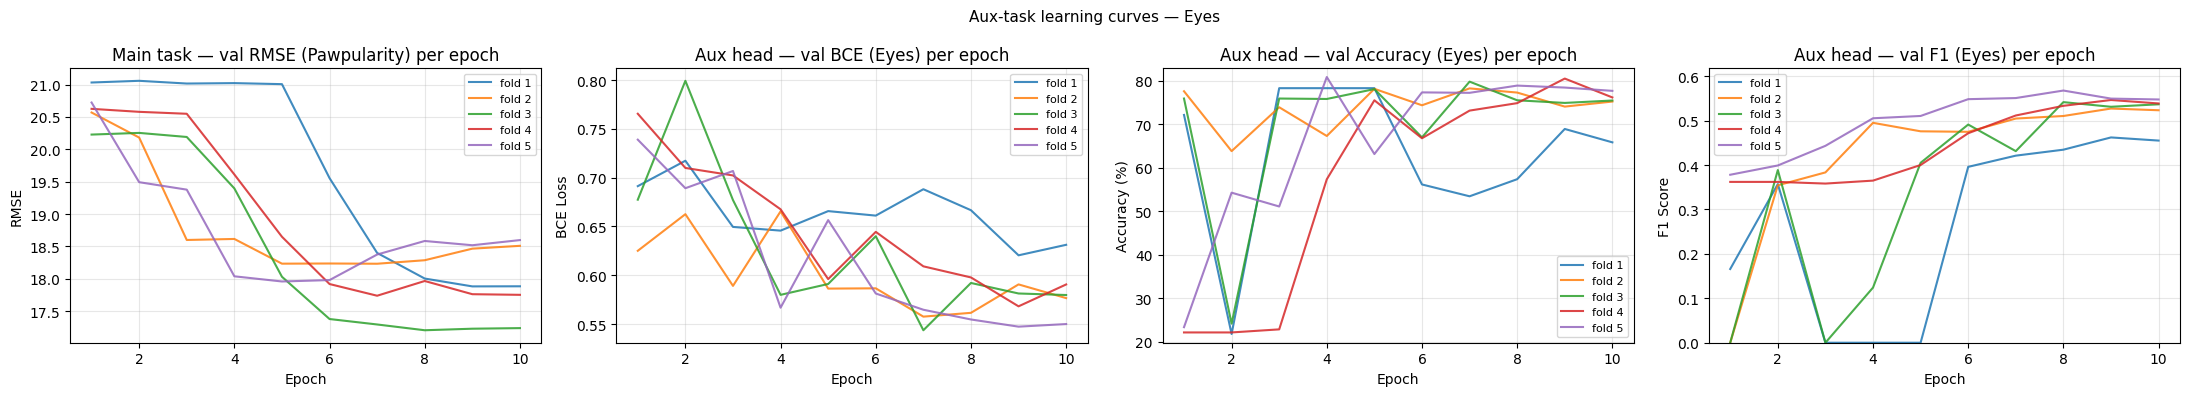

In [10]:
from src.plot import plot_metadata_aux_curves

BACKBONE = "swin_large_patch4_window12_384"
IMG_SIZE  = 384

# plot curves
plot_metadata_aux_curves(
    out_dir=out_dir,
    binary_aux_tasks=cfg["binary_aux_tasks"],
)

### Side by Side Comparison with Image only

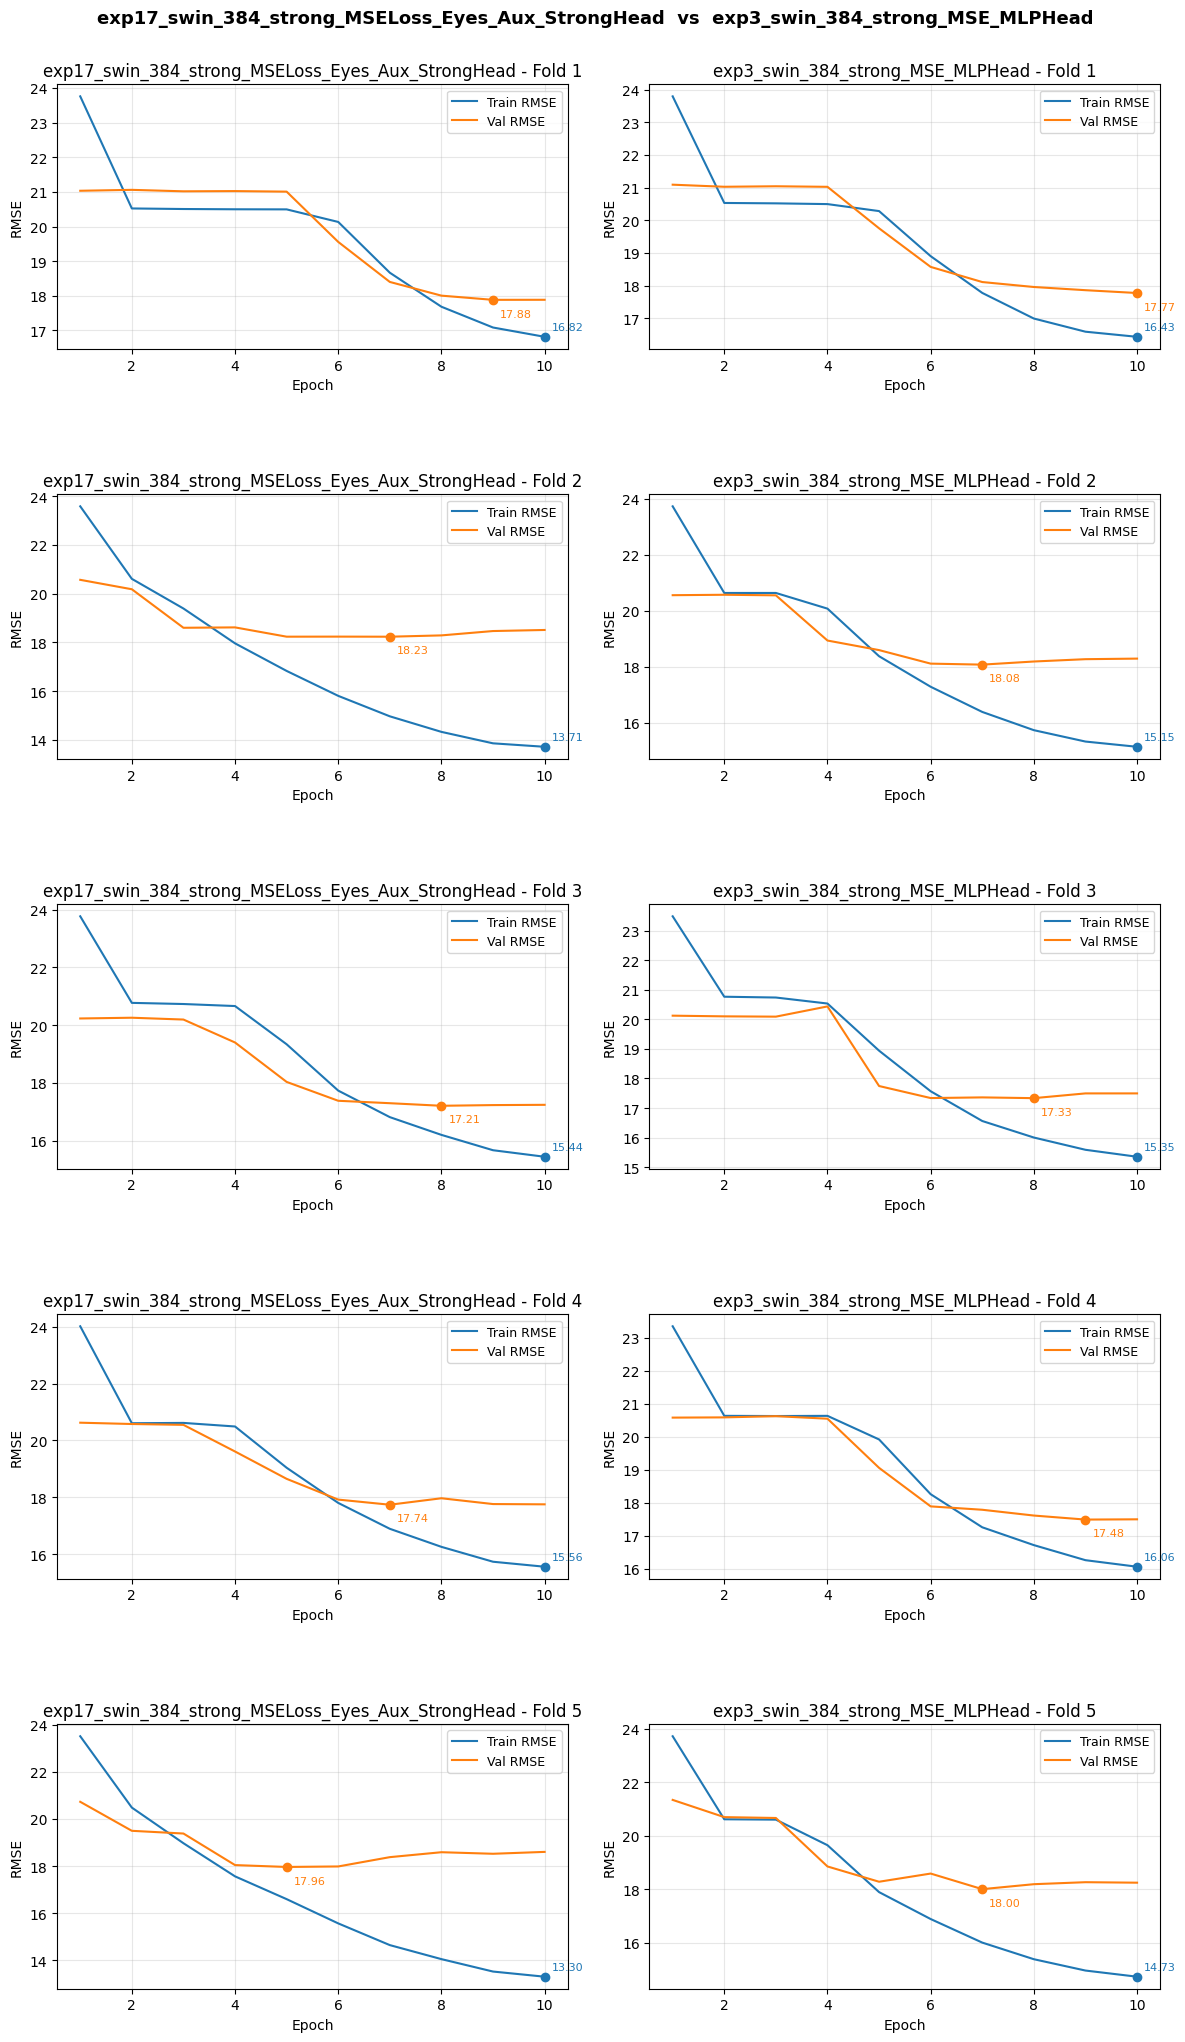

In [11]:
### Side by Side Comparison with Concatenation based Feature Fusion Exp4
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead", label_b="exp3_swin_384_strong_MSE_MLPHead")


In [12]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4c1e05895368c997fdd709bbd1ac3dae,2,2,77.129326,75.129326
1,b2a389311b683a90c3c9763540a86bab,2,2,76.429443,74.429443
2,e638853bdec13e6cc76b69f169b34740,4,96,21.679653,74.320347
3,4435d6f98ad72782ca0cf61f946b016d,5,100,27.380190,72.619810
4,2de3bf4fdcefa2f3c5e5b77fa1e3d262,2,5,77.178909,72.178909


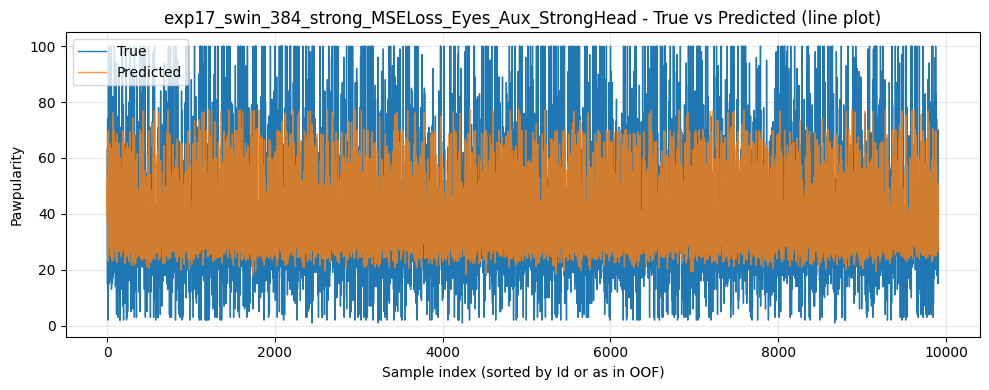

In [13]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead")





exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead OOF RMSE: 17.807634059134088
exp3_swin_384_strong_MSE_MLPHead OOF RMSE: 17.73602090865089
ΔRMSE (exp3_swin_384_strong_MSE_MLPHead - exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead): -0.0716131504831985


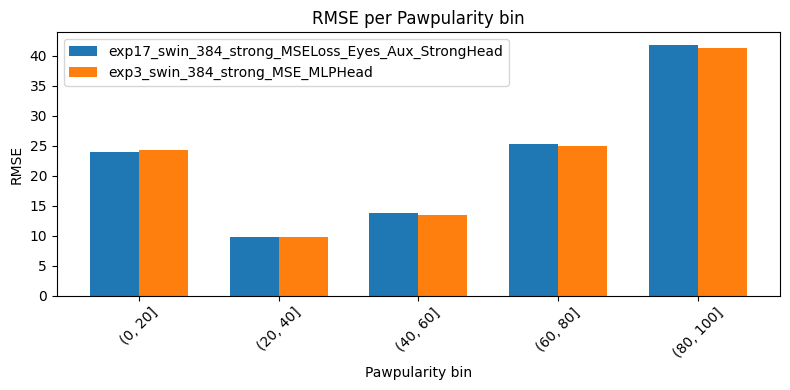

In [14]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead",
    label_b="exp3_swin_384_strong_MSE_MLPHead",
    title_prefix="",
)

In [15]:
df_bins.head()

,bin,count,exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead_rmse,exp3_swin_384_strong_MSE_MLPHead_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.016265,24.383091,0.366826,exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongH...
1,"(20, 40]",5119,9.746805,9.719382,-0.027423,exp3_swin_384_strong_MSE_MLPHead_better
2,"(40, 60]",2088,13.760245,13.504186,-0.256059,exp3_swin_384_strong_MSE_MLPHead_better
3,"(60, 80]",727,25.224968,25.028708,-0.196260,exp3_swin_384_strong_MSE_MLPHead_better
4,"(80, 100]",561,41.831242,41.275555,-0.555686,exp3_swin_384_strong_MSE_MLPHead_better


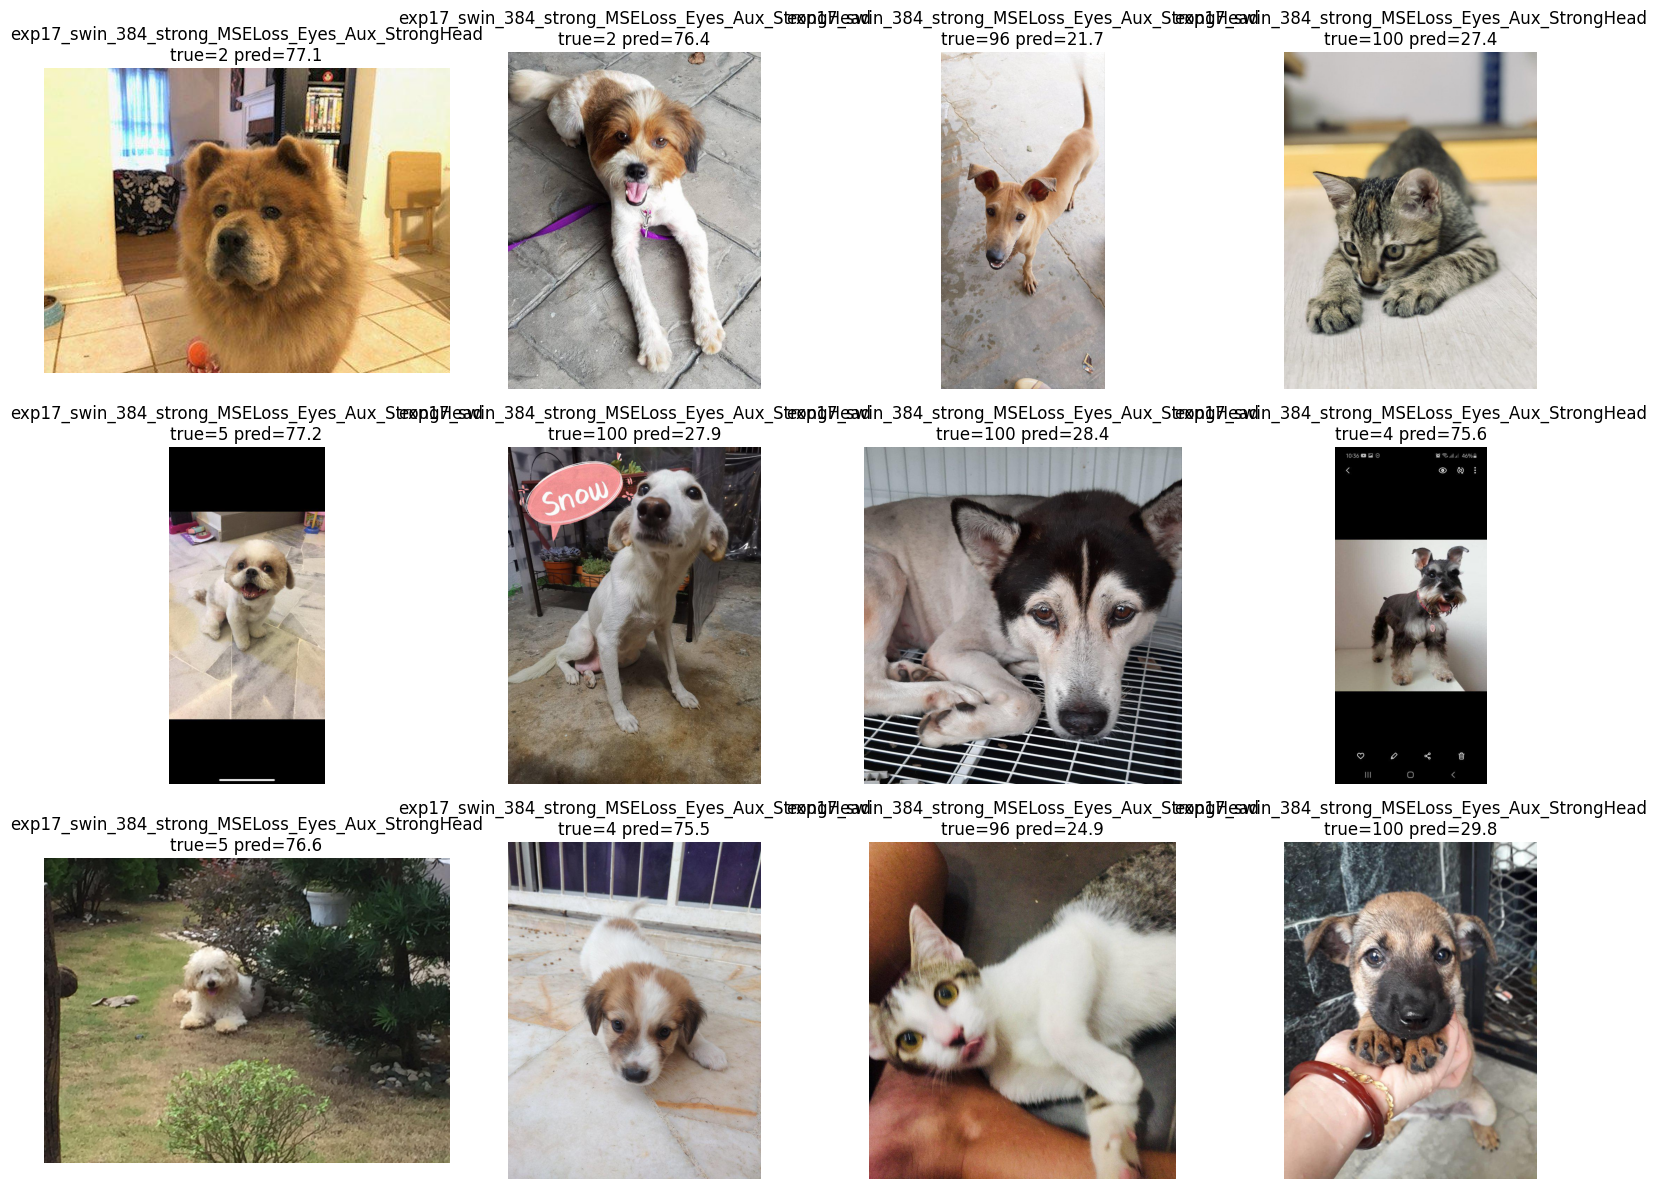

In [16]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead")

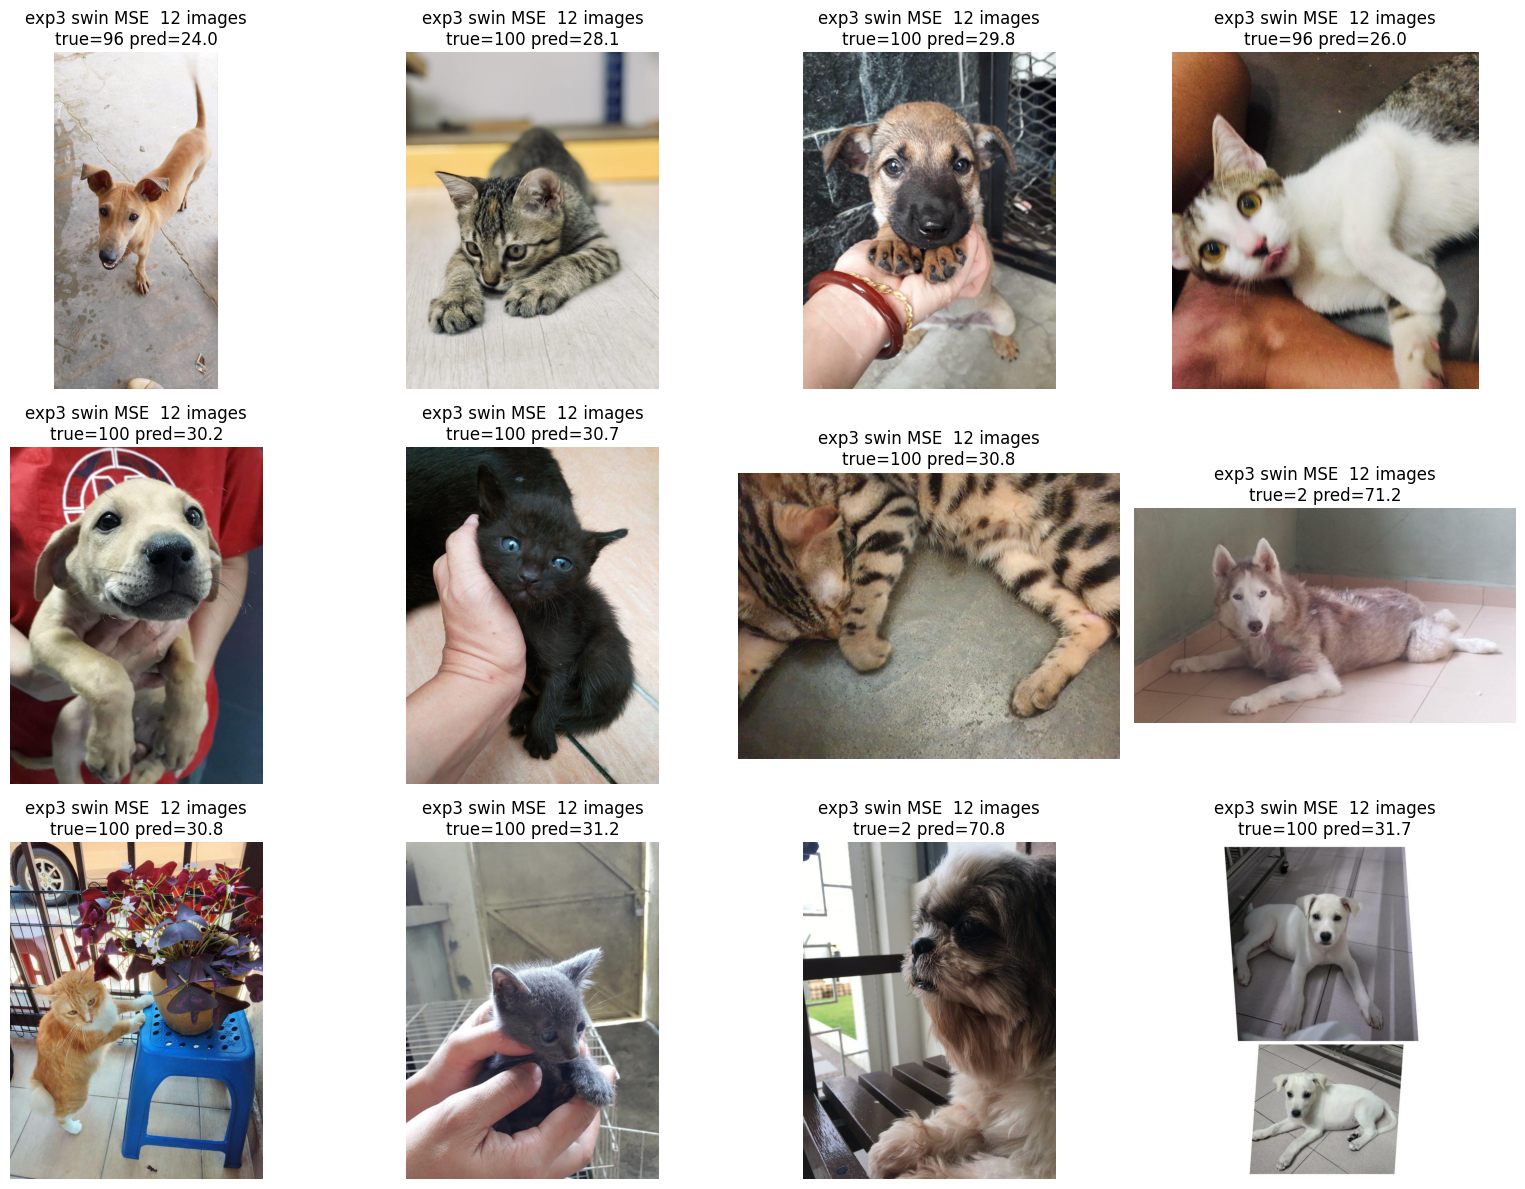

In [17]:
# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp3 swin MSE  12 images")